In [1]:
import csv
import numpy as np
import matplotlib.pyplot as plt
import math

file_path = 'C:\\Users\\USER F\\Desktop\\419\\2 курс\\Вычислительные методы\\3\\09_Москва.csv'

mass_str = []

with open(file_path, newline='') as csvfile:
    reader = csv.reader(csvfile)
    for row in reader:
        mass_str.append(row)

mass = []
for row in mass_str[1:]:
    mass.append(list(map(float, row)))

for row in mass[:5]:
    print(row)

[1779.0, 999.9, 999.9, 999.9, 999.9, 999.9, 999.9, 999.9, 999.9, 999.9, 999.9, -2.1, -5.2, 999.9]
[1780.0, -16.7, -12.0, -1.0, 6.7, 12.3, 15.0, 19.7, 14.1, 7.5, 4.4, -1.9, -10.8, 3.1]
[1781.0, -12.5, -14.9, -5.0, 1.8, 10.9, 14.4, 17.6, 18.4, 11.9, 3.3, 2.6, -11.2, 3.1]
[1782.0, -9.5, -16.6, -2.7, 2.9, 11.8, 15.0, 17.5, 16.5, 11.3, 6.2, -0.4, -13.1, 3.2]
[1783.0, -19.0, -7.0, -5.3, 4.4, 15.8, 19.6, 16.5, 17.7, 999.9, 999.9, 999.9, 999.9, 999.9]


In [6]:
x=[]
y=[]
a=50     #первый год        
b=61    #последний год
c=6     #столбец(месяц) 
for i in range(a-1, b):
    if mass[i][c]!=999.9:
        x+=[mass[i][0]]
        y+=[mass[i][c]]
   
print(x)
print(y)

[1828.0, 1829.0, 1830.0, 1831.0, 1832.0, 1833.0, 1834.0, 1835.0, 1836.0, 1837.0, 1838.0, 1839.0]
[16.7, 17.5, 17.7, 17.8, 14.7, 19.6, 16.6, 16.4, 15.4, 16.0, 14.6, 16.2]


[1828.0, 1829.0, 1830.0, 1831.0, 1832.0, 1833.0, 1834.0, 1835.0, 1836.0, 1837.0, 1838.0, 1839.0] [16.7, 17.5, 17.7, 17.8, 14.7, 19.6, 16.6, 16.4, 15.4, 16.0, 14.6, 16.2]


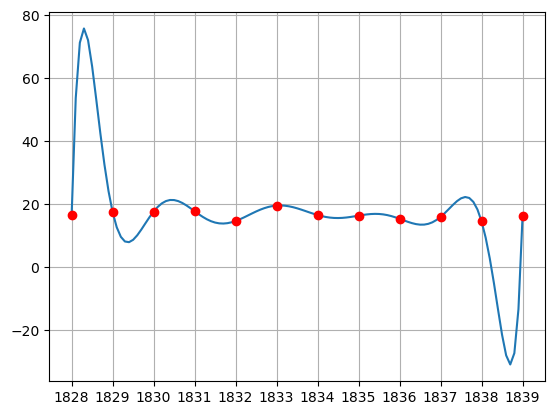

In [7]:
def li(i, a):
    l=1
    for j in range(len(y)):
        if i!=j:
            l*=(a-x[j])/(x[i]-x[j])
    return l
def L(x):
    m=[y[i]*li(i, x) for i in range(len(y))]
    s=0
    for elem in m:
        s+=elem
    return s

x1=np.arange(min(x),max(x)+0.1, 0.1)
y1=L(x1)

plt.plot(x1, y1)
plt.plot(x, y, 'ro')
plt.xticks(np.arange(min(x),max(x)+0.1, 1))
plt.grid()
print(x, y)

[1780.0, 1781.0, 1782.0, 1783.0, 1785.0, 1786.0, 1788.0, 1789.0] [15.0, 14.4, 15.0, 19.6, 16.1, 15.6, 16.9, 15.9]


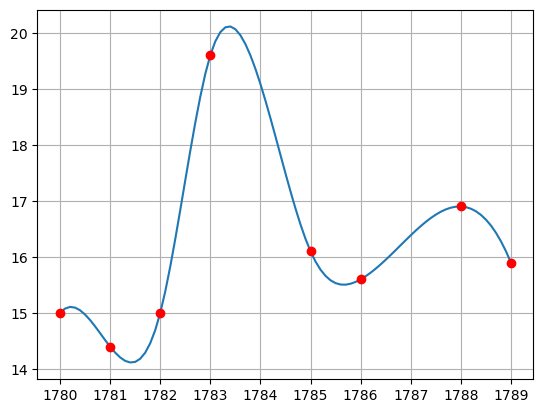

In [4]:
from scipy.interpolate import CubicSpline

cs = CubicSpline(x, y)

x2 = np.arange(min(x),max(x)+0.1, 0.1)
y2 = cs(x2)

plt.plot(x2, y2)
plt.plot(x, y, 'ro')
plt.xticks(np.arange(min(x),max(x)+0.1, 1))
plt.grid()
print(x, y)

[1829.0, 1830.0, 1831.0, 1832.0, 1833.0, 1834.0] [17.5, 17.7, 17.8, 14.7, 19.6, 16.6]


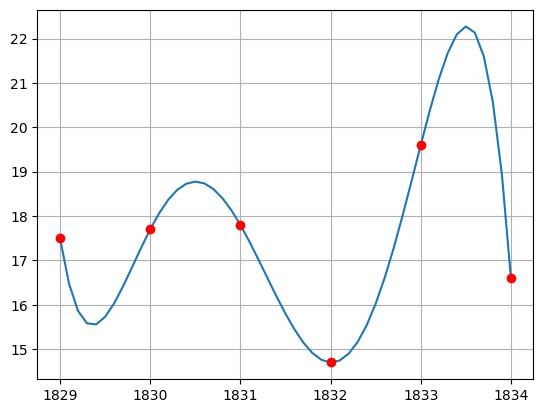

In [8]:
x=[]
y=[]
a=51     #первый год        
b=56    #последний год
c=6     #столбец(месяц) 
for i in range(a-1, b):
    if mass[i][c]!=999.9:
        x+=[mass[i][0]]
        y+=[mass[i][c]]

def newton_1(x_new, x, y):
    n = len(x)
    F = [[0]*n for _ in range(n)]
    for i in range(n):
        F[i][0] = y[i]
    for j in range(1, n):
        for i in range(n-j):
            F[i][j] = (F[i+1][j-1] - F[i][j-1])/(x[i+j] - x[i])
    result = F[0][0]
    product = 1
    for j in range(1, n):
        product *= (x_new - x[j-1])
        result += F[0][j] * product
    return result

x1=np.arange(min(x),max(x)+0.1, 0.1)
y1=newton_1(x1, x, y)

plt.plot(x1, y1)
plt.plot(x, y, 'ro')
plt.xticks(np.arange(min(x),max(x)+0.1, 1))
plt.grid()
print(x, y)

[1835.0, 1836.0, 1837.0, 1838.0, 1839.0, 1840.0] [16.4, 15.4, 16.0, 14.6, 16.2, 16.4]


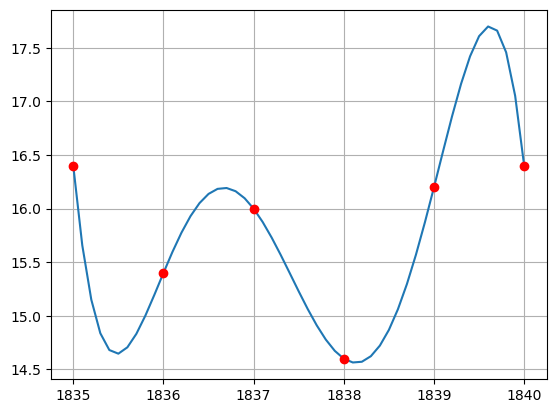

In [9]:
x=[]
y=[]
a=57     #первый год        
b=62    #последний год
c=6     #столбец(месяц) 
for i in range(a-1, b):
    if mass[i][c]!=999.9:
        x+=[mass[i][0]]
        y+=[mass[i][c]]

def newton_2(x_new, x, y):
    n = len(x)
    F = [[0]*n for _ in range(n)]
    for i in range(n):
        F[i][0] = y[i]
    for j in range(1, n):
        for i in range(n-j):
            F[i][j] = (F[i+1][j-1] - F[i][j-1])/(x[i+j] - x[i])
    result = F[-1][0]
    product = 1
    for j in range(1, n):
        product *= (x_new - x[-j])
        result += F[-j-1][j] * product
    return result

x1=np.arange(min(x),max(x)+0.1, 0.1)
y1=newton_2(x1, x, y)

plt.plot(x1, y1)
plt.plot(x, y, 'ro')
plt.xticks(np.arange(min(x),max(x)+0.1, 1))
plt.grid()
print(x, y)

[ 1.65000000e+01 -7.35368661e-01 -2.66759854e-02 -8.16984581e-05
  5.39329541e-06  4.74907377e-08]


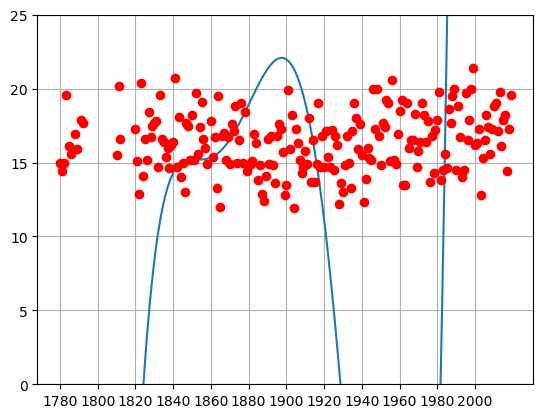

In [3]:
x=[]
y=[]
a=1     #первый год        
b=241    #последний год
c=6     #столбец(месяц)
for i in range(a-1, b):
    if mass[i][c]!=999.9:
        x+=[mass[i][0]]
        y+=[mass[i][c]]
        

x0 = x[int(len(x)/2)]
x1 = x[int(len(x)/1.2)]
x2 = x[int(len(x)/3)]
x3 = x[int(len(x)/4)]
x4 = x[int(len(x)/5)]
x5 = x[int(len(x)/6)]
y0 = y[int(len(x)/2)]
y1 = y[int(len(x)/1.2)]
y2 = y[int(len(x)/3)]
y3 = y[int(len(x)/4)]
y4 = y[int(len(x)/5)]
y5 = y[int(len(x)/6)]

def approximation(x00, x11, x22, x33, x44, x55, y00, y11, y22, y33, y44, y55):
    
    matrix = np.array([
        [1, 0, 0, 0, 0, 0],
        [1, (x11 - x00), (x11 - x00)**2, (x11 - x00)**3, (x11 - x00)**4, (x11 - x00)**5],
        [1, (x22 - x00), (x22 - x00)**2, (x22 - x00)**3, (x22 - x00)**4, (x22 - x00)**5],
        [1, (x33 - x00), (x33 - x00)**2, (x33 - x00)**3, (x33 - x00)**4, (x33 - x00)**5],
        [1, (x44 - x00), (x44 - x00)**2, (x44 - x00)**3, (x44 - x00)**4, (x44 - x00)**5],
        [1, (x55 - x00), (x55 - x00)**2, (x55 - x00)**3, (x55 - x00)**4, (x55 - x00)**5]
    ])
    
    b = np.array([y00,
              y11,
              y22,
              y33,
              y44,
              y55])
    
    solution = np.linalg.solve(matrix, b)
    return solution

array = approximation(x0, x1, x2, x3, x4, x5, y0, y1, y2, y3, y4, y5)
print(array)

x_new=np.arange(min(x),max(x)+0.1, 0.1)
y_new=array[0]+array[1]*(x_new-x0)**1+array[2]*(x_new-x0)**2+array[3]*(x_new-x0)**3+array[4]*(x_new-x0)**4+array[5]*(x_new-x0)**5

plt.plot(x_new, y_new)
plt.plot(x, y, 'ro')
plt.ylim(0, 25)
plt.xticks(np.arange(min(x),max(x)+0.1, 20))
plt.grid()

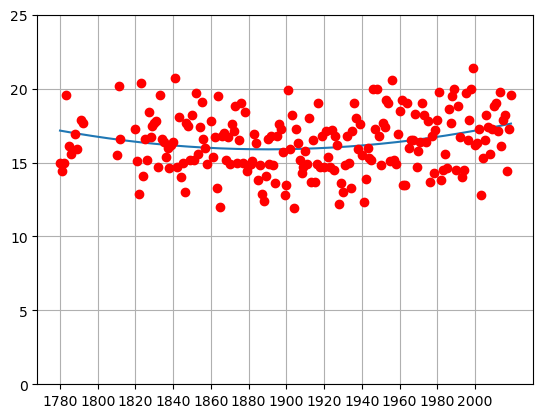

In [10]:
h = 0.1
x=[]
y=[]
a=1     #первый год        
b=241    #последний год
c=6     #столбец(месяц) 
for i in range(a-1, b):
    if mass[i][c]!=999.9:
        x+=[mass[i][0]]
        y+=[mass[i][c]]

def gauss_elimination(matrix, vector):
    n = len(vector)
    for i in range(n):
        max_row = i
        for j in range(i, n):
            if abs(matrix[j][i]) > abs(matrix[max_row][i]):
                max_row = j
        matrix[i], matrix[max_row] = matrix[max_row], matrix[i]
        vector[i], vector[max_row] = vector[max_row], vector[i]
        pivot = matrix[i][i]
        if abs(pivot) < 1e-10:
            return None   
        for j in range(i, n):
            matrix[i][j] /= pivot
        vector[i] /= pivot
        for k in range(i+1, n):
            factor = matrix[k][i]
            for j in range(i, n):
                matrix[k][j] -= factor * matrix[i][j]
            vector[k] -= factor * vector[i]
    solution = [0] * n
    for i in range(n-1, -1, -1):
        solution[i] = vector[i]
        for j in range(i+1, n):
            solution[i] -= matrix[i][j] * solution[j]
    return solution

def polynomial_regression(x_data, y_data, degree=2):
    n = len(x_data)
    matrix_size = degree + 1
    matrix = [[0.0 for _ in range(matrix_size)] for _ in range(matrix_size)]
    vector = [0.0 for _ in range(matrix_size)]
    for i in range(matrix_size):
        for j in range(matrix_size):
            sum_x = 0.0
            for x in x_data:
                sum_x += x ** (i + j)
            matrix[i][j] = sum_x 
        sum_y = 0.0
        for x, y in zip(x_data, y_data):
            sum_y += y * (x ** i)
        vector[i] = sum_y
    coefficients = gauss_elimination(matrix, vector)
    return coefficients

def poly_func(x, coefficients):
    result = 0.0
    for power, coeff in enumerate(coefficients):
        result += coeff * (x ** power)
    return result

degree = 2
coeffs = polynomial_regression(x, y, degree)
min_x = min(x)
max_x = max(x)
x1 = []
current_x = min_x
while current_x <= max_x:
    x1.append(current_x)
    current_x += h
y1 = [poly_func(x, coeffs) for x in x1]

plt.plot(x1, y1)
plt.plot(x, y, 'ro')
plt.ylim(0, 25)
plt.xticks(np.arange(min(x),max(x)+0.1, 20))
plt.grid()